# Phase 1: Exploratory Data Analysis (EDA)
## Credit Card Fraud Detection ML Pipeline

**Objective:** Understand data structure, detect class imbalance, visualize distributions, identify key patterns

**Outputs:**
- EDA plots saved to `/plots/`
- Data summary saved to `/reports/data_summary.txt`
- Key insights documented

## 1. Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## 2. Load Dataset

In [16]:
# Define paths
data_path = Path('../data/raw/creditcard.csv')

# Load dataset
df = pd.read_csv(data_path)
print(f'Shape: {df.shape}')
print(f'Columns: {df.shape[1]}')

Shape: (284807, 31)
Columns: 31


## 3. Basic row information

In [17]:
# Display basic info
print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'\nShape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())

print(f'\n\nData Types:')
print(df.dtypes)

print(f'\n\nMissing Values:')
print(df.isnull().sum())
print(f'Total NaN: {df.isnull().sum().sum()}')

print(f'\n\nDuplicates:')
print(f'Number of duplicate rows: {df.duplicated().sum()}')

DATASET OVERVIEW

Shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.

## 4. Class Imbalance Detection (CRITICAL)

In [18]:
print('='*60)
print('CLASS DISTRIBUTION - IMBALANCE ANALYSIS')
print('='*60)

# Count fraud vs non-fraud
class_counts = df['Class'].value_counts().sort_index()
print(f'\nClass Distribution:')
print(class_counts)

# Calculate fraud percentage
fraud_count = class_counts[1]
total_count = len(df)
fraud_percentage = (fraud_count / total_count) * 100

print(f'\nFraud Statistics:')
print(f'  Normal transactions:  {class_counts[0]:,} ({(class_counts[0]/total_count)*100:.3f}%)')
print(f'  Fraudulent transactions: {fraud_count:,} ({fraud_percentage:.3f}%)')
print(f'  Imbalance ratio: 1:{int(class_counts[0]/fraud_count)} (normal to fraud)')
print(f'\n⚠️  HIGHLY IMBALANCED DATASET - Will require special handling')

CLASS DISTRIBUTION - IMBALANCE ANALYSIS

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Statistics:
  Normal transactions:  284,315 (99.827%)
  Fraudulent transactions: 492 (0.173%)
  Imbalance ratio: 1:577 (normal to fraud)

⚠️  HIGHLY IMBALANCED DATASET - Will require special handling


## 5. Class Distribution Visualization

✓ Saved: 01_class_distribution.png


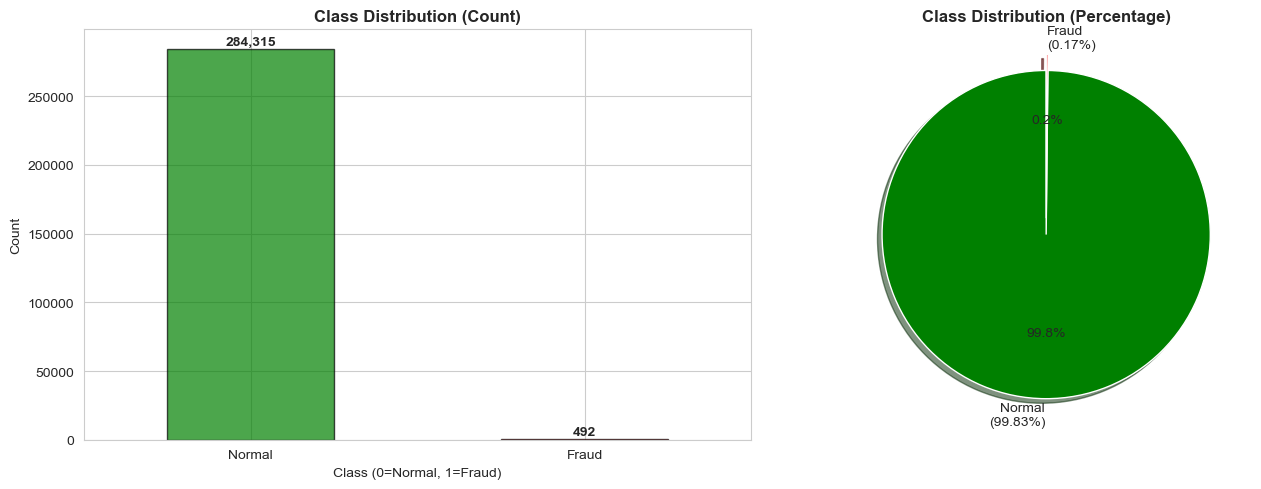

In [19]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot - count
class_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal', 'Fraud'], rotation=0)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 3000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart - percentage
colors = ['green', 'red']
labels = [f'Normal\n({(class_counts[0]/total_count)*100:.2f}%)', 
          f'Fraud\n({fraud_percentage:.2f}%)']
axes[1].pie(class_counts, labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=90, explode=(0, 0.1), shadow=True)
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(plots_path / '01_class_distribution.png', dpi=300, bbox_inches='tight')
print('✓ Saved: 01_class_distribution.png')
plt.show()

## 6. Statistical Summary

In [20]:
print('='*60)
print('STATISTICAL SUMMARY')
print('='*60)

summary_stats = df.describe()
print(summary_stats)

STATISTICAL SUMMARY
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1

## 7. Correlation Analysis

✓ Saved: 02_correlation_matrix.png


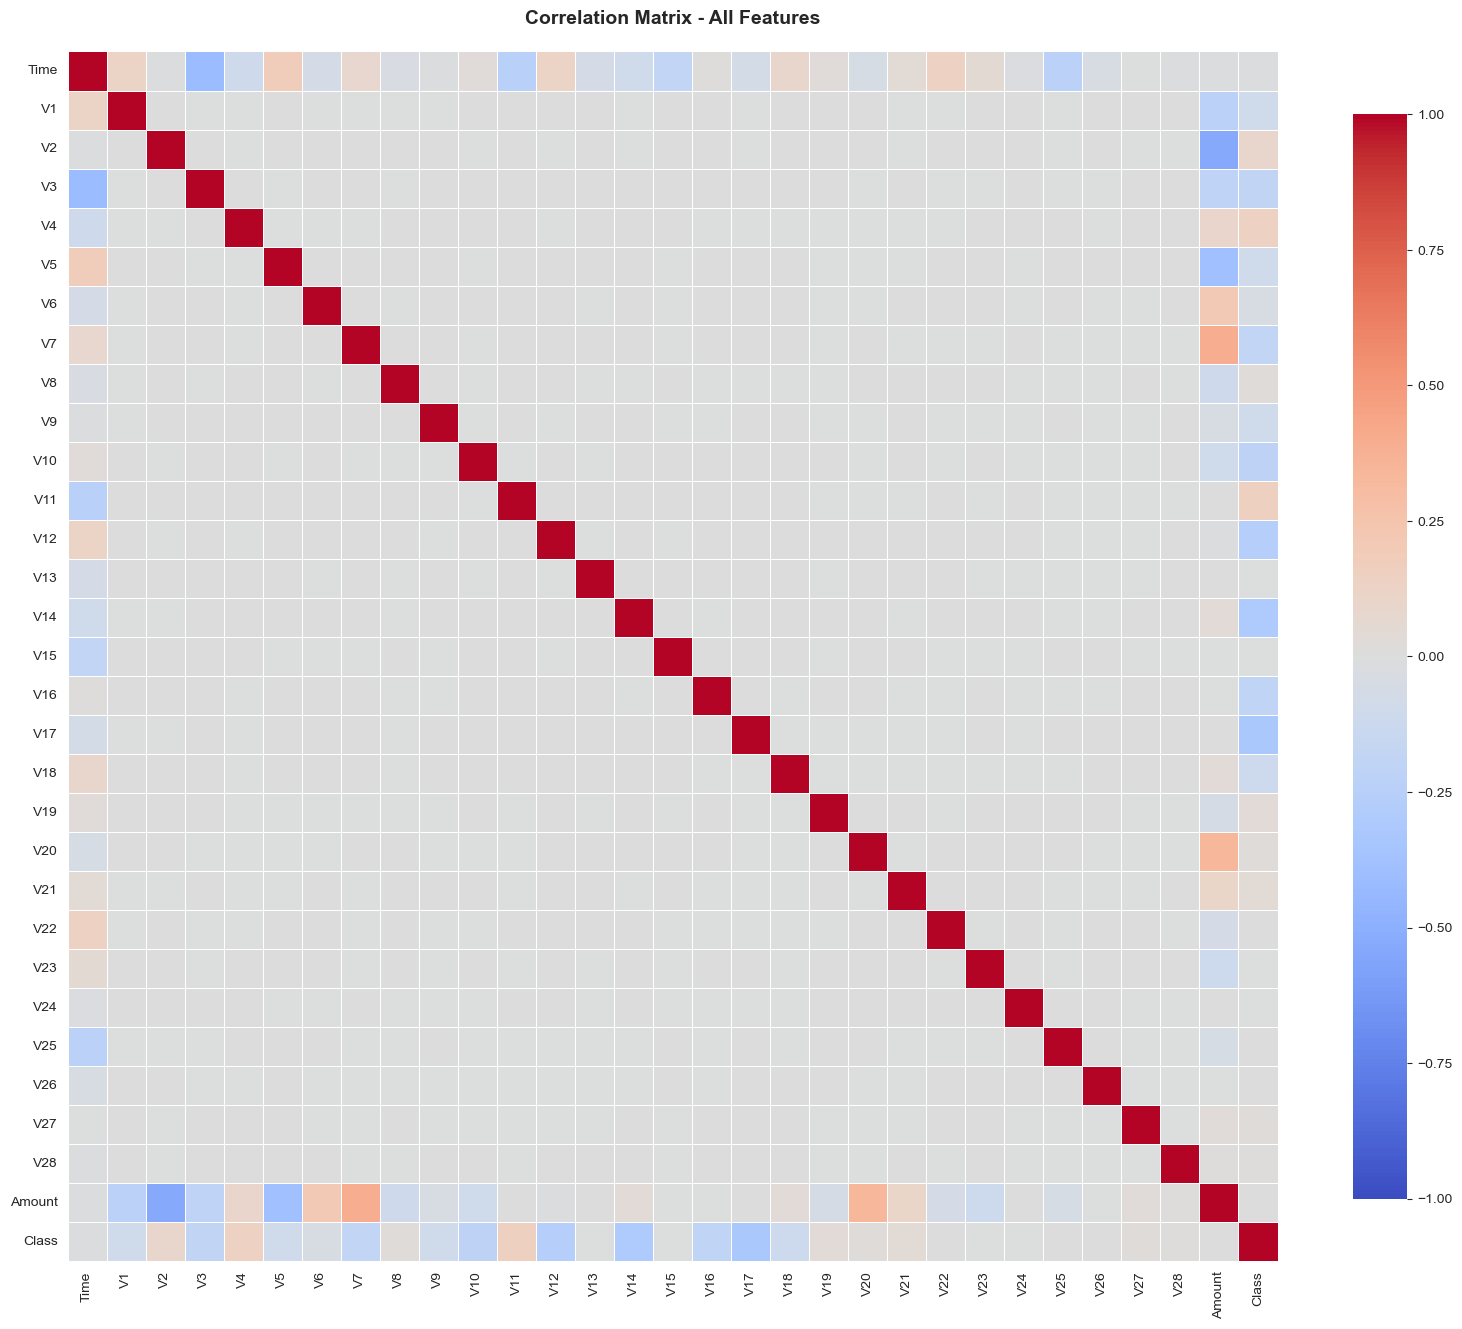


Top 10 Features Correlated with Fraud (Class):
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64

---

V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [21]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1) # Set vmin and vmax for consistent color scaling   
plt.title('Correlation Matrix - All Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(plots_path / '02_correlation_matrix.png', dpi=300, bbox_inches='tight')
print('✓ Saved: 02_correlation_matrix.png')
plt.show()

# Find correlation with target
print('\nTop 10 Features Correlated with Fraud (Class):')
class_corr = correlation_matrix['Class'].sort_values(ascending=False)
print(class_corr.head(11))  # Include Class itself
print('\n---\n')
print(class_corr.tail(10))  # Most negatively correlated

## 8. Feature Distributions by Class

In [22]:
# Select key features based on correlation with fraud
top_corr_features = class_corr.iloc[1:7].index.tolist()  # Top 6 features (excluding Class)
bottom_corr_features = class_corr.iloc[-6:].index.tolist()  # Bottom 6 features
key_features = top_corr_features + bottom_corr_features + ['Amount', 'Time']

print(f'Key Features to Visualize: {key_features}')

Key Features to Visualize: ['V11', 'V4', 'V2', 'V21', 'V19', 'V20', 'V3', 'V16', 'V10', 'V12', 'V14', 'V17', 'Amount', 'Time']


✓ Saved: 03_feature_distributions.png


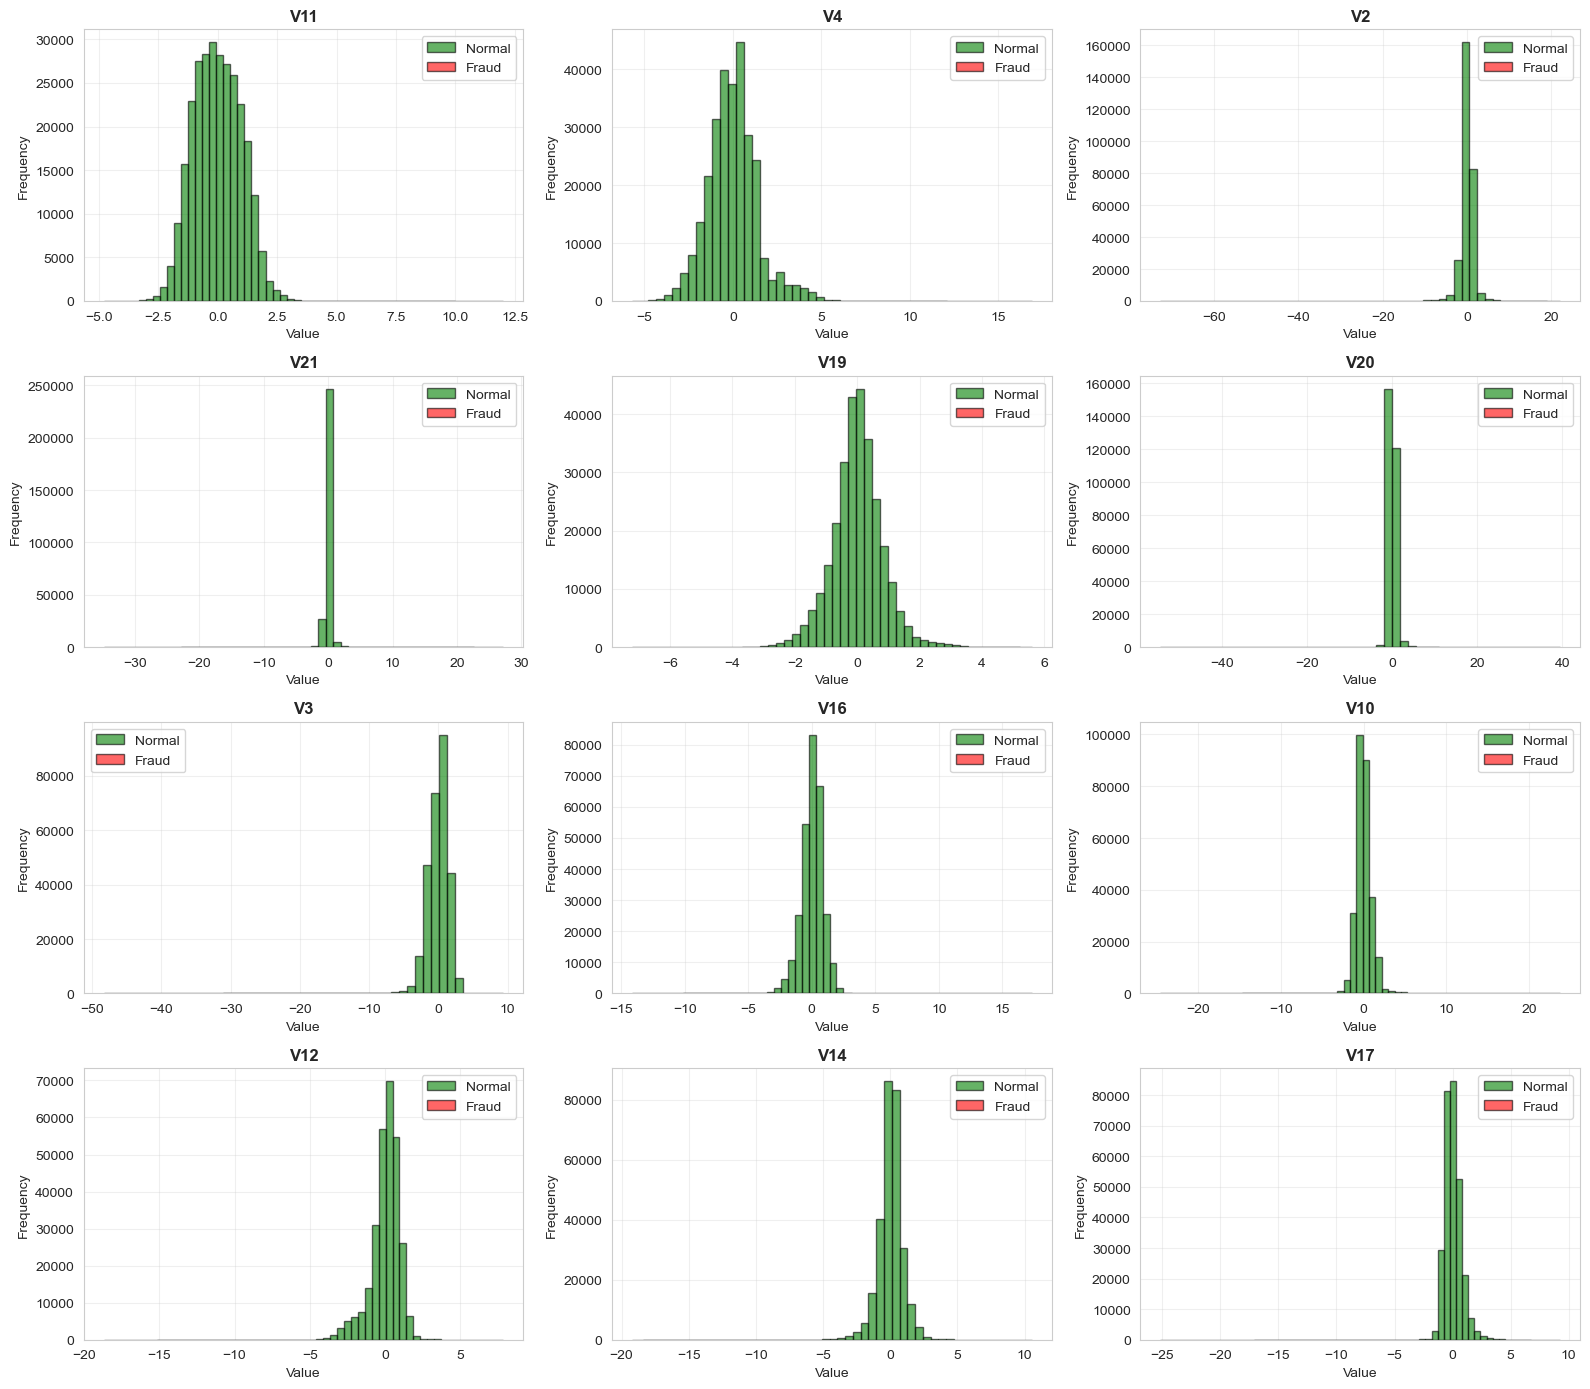

In [23]:
# Plot histograms for selected features (fraud vs normal)
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.ravel()

for idx, feature in enumerate(key_features[:12]):
    # Normal transactions
    axes[idx].hist(df[df['Class'] == 0][feature], bins=50, alpha=0.6, 
                   label='Normal', color='green', edgecolor='black')
    # Fraud transactions
    axes[idx].hist(df[df['Class'] == 1][feature], bins=50, alpha=0.6, 
                   label='Fraud', color='red', edgecolor='black')
    axes[idx].set_title(f'{feature}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(plots_path / '03_feature_distributions.png', dpi=300, bbox_inches='tight')
print('✓ Saved: 03_feature_distributions.png')
plt.show()


## 9. Boxplots for Amount and Time Features

✓ Saved: 04_boxplots_amount_time.png


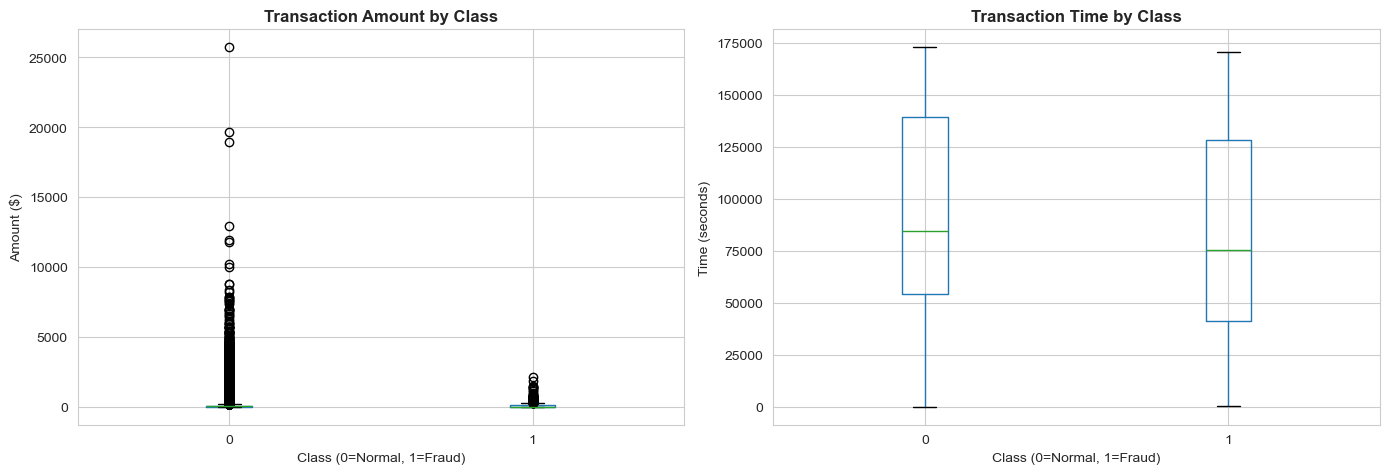

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount boxplot
df.boxplot(column='Amount', by='Class', ax=axes[0])
axes[0].set_title('Transaction Amount by Class', fontweight='bold')
axes[0].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[0].set_ylabel('Amount ($)')
axes[0].get_figure().suptitle('')  # Remove auto title

# Time boxplot
df.boxplot(column='Time', by='Class', ax=axes[1])
axes[1].set_title('Transaction Time by Class', fontweight='bold')
axes[1].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[1].set_ylabel('Time (seconds)')
axes[1].get_figure().suptitle('')  # Remove auto title

plt.tight_layout()
plt.savefig(plots_path / '04_boxplots_amount_time.png', dpi=300, bbox_inches='tight')
print('✓ Saved: 04_boxplots_amount_time.png')
plt.show()

## 10. Amount Statistics by Class

In [25]:
print('='*60)
print('AMOUNT STATISTICS BY CLASS')
print('='*60)

for class_label in [0, 1]:
    class_name = 'Normal' if class_label == 0 else 'Fraud'
    amount_stats = df[df['Class'] == class_label]['Amount'].describe()
    print(f'\n{class_name} Transactions:')
    print(amount_stats)
    print(f'  Median: ${amount_stats["50%"]:.2f}')
    print(f'  Mean: ${amount_stats["mean"]:.2f}')

AMOUNT STATISTICS BY CLASS

Normal Transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64
  Median: $22.00
  Mean: $88.29

Fraud Transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
  Median: $9.25
  Mean: $122.21


## 11. Key Insights Summary

In [ ]:
insights = f"""
================================================================================
EXPLORATORY DATA ANALYSIS - KEY INSIGHTS
================================================================================

1. DATASET OVERVIEW
   - Total transactions: {len(df):,}
   - Features: {df.shape[1]}
   - Data types: All numeric (suitable for ML)
   - Missing values: None detected ✓
   - Duplicate rows: {df.duplicated().sum()} rows ⚠️  (MUST REMOVE in preprocessing)

2. CLASS IMBALANCE (CRITICAL)
   - Normal transactions: {class_counts[0]:,} ({(class_counts[0]/total_count)*100:.3f}%)
   - Fraudulent transactions: {fraud_count:,} ({fraud_percentage:.3f}%)
   - Imbalance ratio: 1:{int(class_counts[0]/fraud_count)}
   ⚠️  HIGHLY IMBALANCED - Standard accuracy metrics will be misleading
   ✓ Must use class weights or SMOTE in training phase
   ✓ Must prioritize Recall and ROC-AUC over accuracy

3. FEATURE CHARACTERISTICS
   - 28 features (V1-V28): PCA-transformed components
   - 1 feature: Time (seconds since first transaction)
   - 1 feature: Amount (transaction amount in dollars) - HIGHLY SKEWED ⚠️
   - All features already scaled (except Amount/Time)

4. CORRELATION WITH FRAUD
   Most positively correlated with fraud:
{pd.DataFrame({'Feature': class_corr.iloc[1:4].index, 'Correlation': class_corr.iloc[1:4].values}).to_string(index=False)}

   Most negatively correlated with fraud:
{pd.DataFrame({'Feature': class_corr.iloc[-3:].index, 'Correlation': class_corr.iloc[-3:].values}).to_string(index=False)}

5. AMOUNT ANALYSIS
   - Normal transactions: Mean ${df[df['Class']==0]['Amount'].mean():.2f}, Median ${df[df['Class']==0]['Amount'].median():.2f}
   - Fraudulent transactions: Mean ${df[df['Class']==1]['Amount'].mean():.2f}, Median ${df[df['Class']==1]['Amount'].median():.2f}
   ✓ Fraudulent transactions tend to have smaller amounts
   ⚠️  Amount is skewed - will apply log transformation in preprocessing

6. PREPROCESSING REQUIREMENTS (Phase 2)
   ✓ Remove 1,081 duplicate rows
   ✓ Apply log transformation to Amount (skewed)
   ✓ Scale features with StandardScaler (fit on train data only)
   ✓ Use stratified train/test split (preserve fraud ratio)
   ✓ Handle imbalance: class weights or SMOTE (train only)
   ✓ Prevent data leakage (no test data in training transformations)

7. NEXT STEPS
   ✓ Phase 2: Preprocessing (this notebook's requirements)
   ✓ Phase 3: Training (apply class weights)
   ✓ Phase 4: Hyperparameter tuning
   ✓ Phase 5: Evaluation (Recall, ROC-AUC priority)
   ✓ Phase 6: Model selection
   ✓ Phase 7: SHAP explainability

================================================================================
"""

print(insights)

# Save insights to file
with open(reports_path / 'eda_summary.txt', 'w') as f:
    f.write(insights)

print('\n✓ Saved: eda_summary.txt')


EXPLORATORY DATA ANALYSIS - KEY INSIGHTS

1. DATASET OVERVIEW
   - Total transactions: 284,807
   - Features: 31
   - Data types: All numeric (suitable for ML)
   - Missing values: None detected ✓
   - Duplicates: 1081 rows

2. CLASS IMBALANCE (CRITICAL)
   - Normal transactions: 284,315 (99.827%)
   - Fraudulent transactions: 492 (0.173%)
   - Imbalance ratio: 1:577
       HIGHLY IMBALANCED - Standard accuracy metrics will be misleading
   ✓ Must use class weights or SMOTE in training phase
   ✓ Must prioritize Recall and ROC-AUC over accuracy

3. FEATURE CHARACTERISTICS
   - 28 features (V1-V28): PCA-transformed components
   - 1 feature: Time (seconds since first transaction)
   - 1 feature: Amount (transaction amount in dollars)
   - All features already scaled (except Amount/Time)

4. CORRELATION WITH FRAUD
   Most positively correlated with fraud:
Feature  Correlation
    V11     0.154876
     V4     0.133447
     V2     0.091289

   Most negatively correlated with fraud:
Featur

## 12. Data Ready for Preprocessing

 **EDA Complete**

Key findings:
- Number of duplicate rows: 1081
- Highly imbalanced: 0.17% fraud
- Clear feature differentiation between fraud/normal
- Ready for preprocessing → training → evaluation

**Next:** Run `02_preprocessing.ipynb`